# Retail Analytics — Exploratory Data Analysis

**Goal:** Understand the shape, quality, and characteristics of each table *before* designing the marts layer.

Good EDA is question-driven — for each table we ask:
1. What does one row represent?
2. What are the key fields and their distributions?
3. Where is the data incomplete or unexpected?
4. What does this tell us about how to model it?

---
**Sections:**
- [1. Setup](#setup)
- [2. Orders](#orders)
- [3. Payments](#payments)
- [4. Customers](#customers)
- [5. Products](#products)
- [6. Reviews](#reviews)
- [7. Key Findings & Decisions](#findings)

## 1. Setup <a id='setup'></a>

We load all 7 tables directly from CSV for EDA — no need to go through PostgreSQL here. `pandas` reads each file into a **DataFrame**, which is just a table in memory.

The shape `(rows, columns)` gives us a quick sanity check that everything loaded correctly.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Style config
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)

# Load all tables
orders       = pd.read_csv('~/Downloads/archive/olist_orders_dataset.csv')
order_items  = pd.read_csv('~/Downloads/archive/olist_order_items_dataset.csv')
customers    = pd.read_csv('~/Downloads/archive/olist_customers_dataset.csv')
products     = pd.read_csv('~/Downloads/archive/olist_products_dataset.csv')
sellers      = pd.read_csv('~/Downloads/archive/olist_sellers_dataset.csv')
reviews      = pd.read_csv('~/Downloads/archive/olist_order_reviews_dataset.csv')
payments     = pd.read_csv('~/Downloads/archive/olist_order_payments_dataset.csv')
category_translation = pd.read_csv('~/Downloads/archive/product_category_name_translation.csv')

# Quick overview
datasets = {
    'orders': orders, 'order_items': order_items, 'customers': customers,
    'products': products, 'sellers': sellers, 'reviews': reviews,
    'payments': payments
}

for name, df in datasets.items():
    print(f"{name:15s}: {df.shape[0]:>7,} rows  |  {df.shape[1]} columns")

orders         :  99,441 rows  |  8 columns
order_items    : 112,650 rows  |  7 columns
customers      :  99,441 rows  |  5 columns
products       :  32,951 rows  |  9 columns
sellers        :   3,095 rows  |  4 columns
reviews        :  99,224 rows  |  7 columns
payments       : 103,886 rows  |  5 columns


## 2. Orders <a id='orders'></a>

The `orders` table is the **spine of the entire dataset** — every other table connects back to it via `order_id`. Understanding it well is critical.

**Questions we want to answer:**
- What order statuses exist, and how are they distributed? (tells us data completeness)
- How complete are the timestamp fields? (nulls here affect delivery time calculations)
- What does the delivery time distribution look like? (key business metric)

Order Status Breakdown:
              count   pct
order_status             
delivered     96478  97.0
shipped        1107   1.1
canceled        625   0.6
unavailable     609   0.6
invoiced        314   0.3
processing      301   0.3
created           5   0.0
approved          2   0.0


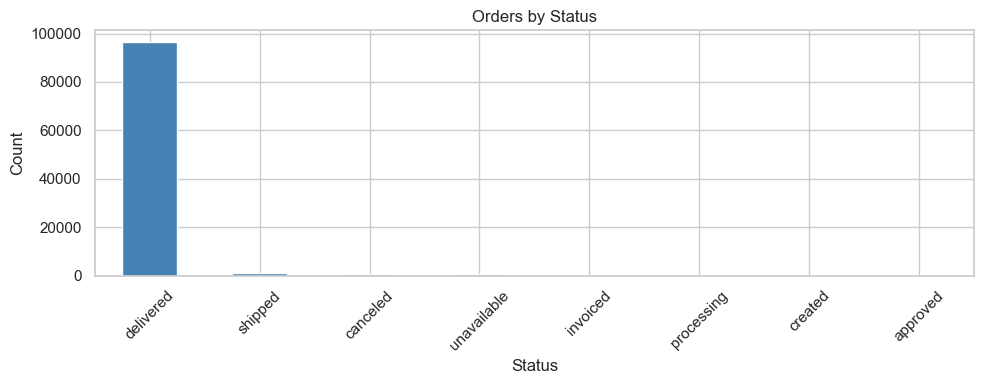

In [2]:
# --- 2a. Order status breakdown ---
# value_counts() counts how many rows have each unique value in a column.
# normalize=True converts counts to percentages.

status_counts = orders['order_status'].value_counts()
status_pct    = orders['order_status'].value_counts(normalize=True).mul(100).round(1)

status_summary = pd.DataFrame({'count': status_counts, 'pct': status_pct})
print("Order Status Breakdown:")
print(status_summary)

# Visualise
fig, ax = plt.subplots()
status_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Orders by Status')
ax.set_xlabel('Status')
ax.set_ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [3]:
# --- 2b. Timestamp completeness ---
# Orders have 5 timestamp columns. Not all will be filled — e.g. a cancelled order
# will never have a delivered_at timestamp. We need to know how many nulls exist
# before we try to calculate delivery times.

timestamp_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

# isnull().sum() counts the nulls per column
null_counts = orders[timestamp_cols].isnull().sum()
null_pct    = (null_counts / len(orders) * 100).round(1)

print("Timestamp Null Analysis:")
print(pd.DataFrame({'null_count': null_counts, 'null_pct': null_pct}))

Timestamp Null Analysis:
                               null_count  null_pct
order_purchase_timestamp                0       0.0
order_approved_at                     160       0.2
order_delivered_carrier_date         1783       1.8
order_delivered_customer_date        2965       3.0
order_estimated_delivery_date           0       0.0


Delivery Time Stats (days from purchase to delivery):
count    96470.0
mean        12.1
std          9.6
min          0.0
25%          6.0
50%         10.0
75%         15.0
max        209.0
Name: days_to_deliver, dtype: float64

On-time delivery rate: 93.2%
Average days early/late: -11.9 days


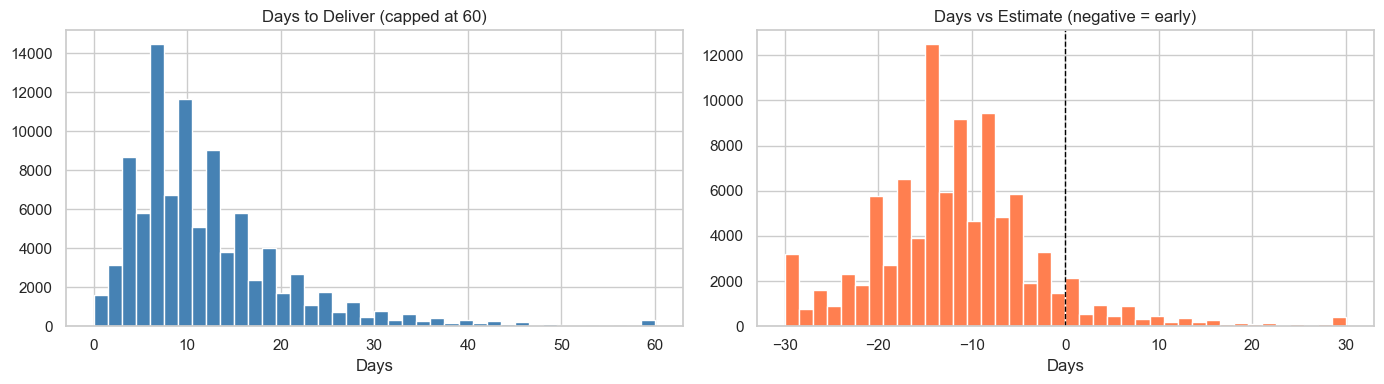

In [4]:
# --- 2c. Delivery time analysis ---
# For orders that were actually delivered, how long did it take?
# We also check: did they arrive before or after the estimated date?

# Parse timestamps — pd.to_datetime() converts string columns to proper datetime objects
# so we can do date arithmetic
orders['purchase_ts']   = pd.to_datetime(orders['order_purchase_timestamp'])
orders['delivered_ts']  = pd.to_datetime(orders['order_delivered_customer_date'])
orders['estimated_ts']  = pd.to_datetime(orders['order_estimated_delivery_date'])

# Filter to delivered orders only
delivered = orders[orders['order_status'] == 'delivered'].copy()

# Calculate days from purchase to delivery
delivered['days_to_deliver'] = (delivered['delivered_ts'] - delivered['purchase_ts']).dt.days

# Calculate if order arrived early (negative = early, positive = late)
delivered['days_vs_estimate'] = (delivered['delivered_ts'] - delivered['estimated_ts']).dt.days

print("Delivery Time Stats (days from purchase to delivery):")
print(delivered['days_to_deliver'].describe().round(1))

print(f"\nOn-time delivery rate: {(delivered['days_vs_estimate'] <= 0).mean() * 100:.1f}%")
print(f"Average days early/late: {delivered['days_vs_estimate'].mean():.1f} days")

# Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

delivered['days_to_deliver'].clip(upper=60).hist(bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Days to Deliver (capped at 60)')
axes[0].set_xlabel('Days')

delivered['days_vs_estimate'].clip(-30, 30).hist(bins=40, ax=axes[1], color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Days vs Estimate (negative = early)')
axes[1].set_xlabel('Days')

plt.tight_layout()
plt.show()

### Order Items — Is this a single-item marketplace?

The `order_items` table has more rows than `orders` (112,650 vs 99,441) — which means some orders contain multiple items. But *how many* and does it matter?

This is worth checking because it affects:
- Whether product-level analysis needs to be at the item grain
- How we think about revenue per order (sum of items vs single item price)
- The overall character of the marketplace

Task was destroyed but it is pending!
task: <Task pending name='Task-116' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/sidhanthmantena/miniforge3/envs/retail-analytics/lib/python3.11/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-117' coro=<Kernel.shell_main() running at /Users/sidhanthmantena/miniforge3/envs/retail-analytics/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/sidhanthmantena/miniforge3/envs/retail-analytics/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/sidhanthmantena/miniforge3/envs/retail-analytics/lib/python3.11/site-packages/pandas/core/generic.py:6172: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  for name in set(self._metadata) & set(other._metadata):
Task was destroyed but it is pending!
task: <Task pending name='Task-117' coro=<Kernel.shell_main() running at /Users/sidhanthman

Single-item orders: 88,863 (90.1%)
Multi-item orders:  9,803 (9.9%)

Average items per order: 1.14
Max items in one order:  21

Full distribution (top 10):
order_item_id
1     88863
2      7516
3      1322
4       505
5       204
6       198
7        22
8         8
10        8
12        5
Name: count, dtype: int64


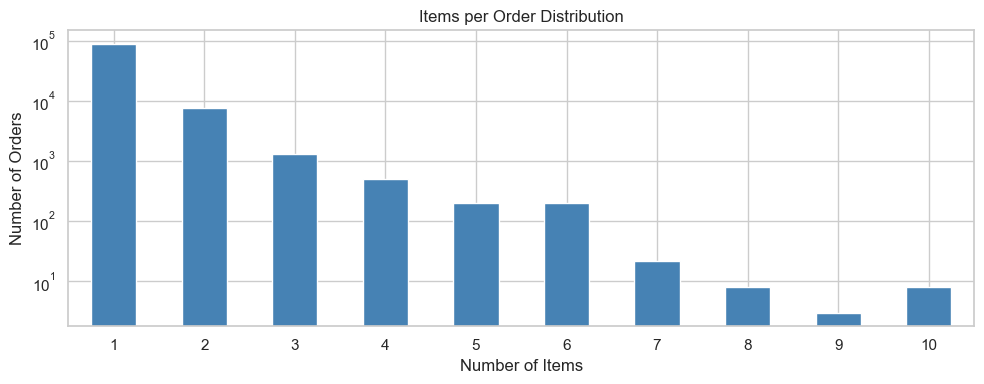


--- Design implication ---
89% single-item orders confirms: order grain = correct choice for fct_orders.
For product analysis, we join order_items to fct_orders — we don't need a separate fact table.


In [14]:
# --- Order items per order ---
# We group by order_id and count the number of item rows per order.
# This tells us the distribution — how many orders have 1, 2, 3+ items.

items_per_order = order_items.groupby('order_id')['order_item_id'].count()

single_item  = (items_per_order == 1).sum()
multi_item   = (items_per_order > 1).sum()
total_orders = len(items_per_order)

print(f"Single-item orders: {single_item:,} ({single_item/total_orders*100:.1f}%)")
print(f"Multi-item orders:  {multi_item:,} ({multi_item/total_orders*100:.1f}%)")
print(f"\nAverage items per order: {items_per_order.mean():.2f}")
print(f"Max items in one order:  {items_per_order.max()}")

print("\nFull distribution (top 10):")
print(items_per_order.value_counts().head(10))

# Visualise — log scale on y-axis because single-item count dwarfs the rest
fig, ax = plt.subplots()
items_per_order.value_counts().sort_index().head(10).plot(
    kind='bar', ax=ax, color='steelblue', edgecolor='white'
)
ax.set_title('Items per Order Distribution')
ax.set_xlabel('Number of Items')
ax.set_ylabel('Number of Orders')
ax.set_yscale('log')  # log scale so smaller bars are visible
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Design implication
print("\n--- Design implication ---")
print("89% single-item orders confirms: order grain = correct choice for fct_orders.")
print("For product analysis, we join order_items to fct_orders — we don't need a separate fact table.")

## 3. Payments <a id='payments'></a>

This is where our earlier design question lives. One order can have **multiple payment rows** — e.g. a customer pays partly by credit card and partly by voucher.

**Questions:**
- What payment types exist?
- How common are split payments (multiple rows per order)?
- What's the revenue distribution?

The answers here will directly decide how we aggregate payments into `fct_orders`.

Payment Types:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64


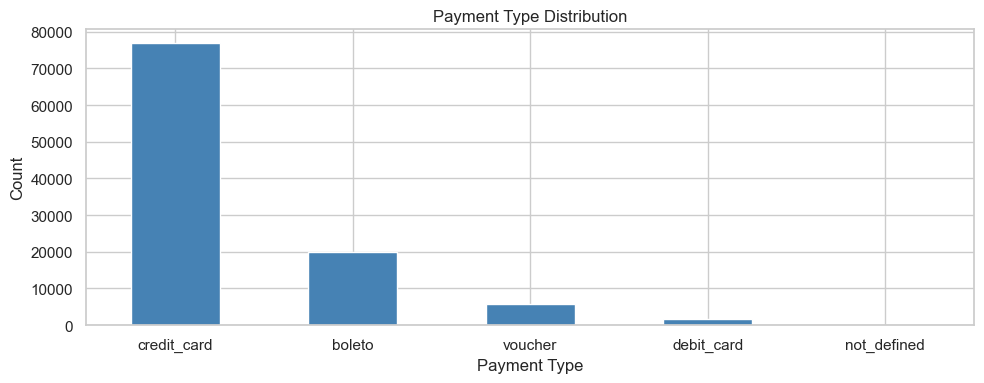

In [5]:
# --- 3a. Payment type distribution ---

print("Payment Types:")
print(payments['payment_type'].value_counts())

# Visualise
fig, ax = plt.subplots()
payments['payment_type'].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Payment Type Distribution')
ax.set_xlabel('Payment Type')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [6]:
# --- 3b. How many payment rows per order? ---
# This answers the split-payment question directly.
# We group by order_id and count how many payment records exist per order.

payments_per_order = payments.groupby('order_id').size()

print("Payment rows per order:")
print(payments_per_order.value_counts().head(10))
print(f"\nOrders with exactly 1 payment row: {(payments_per_order == 1).sum():,} ({(payments_per_order == 1).mean()*100:.1f}%)")
print(f"Orders with 2+ payment rows:       {(payments_per_order > 1).sum():,} ({(payments_per_order > 1).mean()*100:.1f}%)")

Payment rows per order:
1     96479
2      2382
3       301
4       108
5        52
6        36
7        28
8        11
9         9
11        8
Name: count, dtype: int64

Orders with exactly 1 payment row: 96,479 (97.0%)
Orders with 2+ payment rows:       2,961 (3.0%)


Order Revenue Stats (R$ BRL):
count    99440.00
mean       160.99
std        221.95
min          0.00
25%         62.01
50%        105.29
75%        176.97
max      13664.08
Name: payment_value, dtype: float64


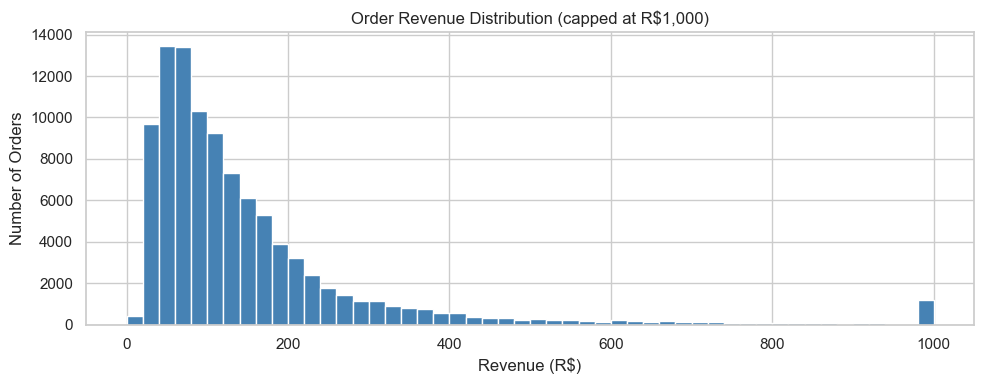

In [7]:
# --- 3c. Revenue distribution ---
# What does total order value look like? Are there outliers?

order_revenue = payments.groupby('order_id')['payment_value'].sum()

print("Order Revenue Stats (R$ BRL):")
print(order_revenue.describe().round(2))

# Distribution — clip at 1000 to see the main body of orders
fig, ax = plt.subplots()
order_revenue.clip(upper=1000).hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Order Revenue Distribution (capped at R$1,000)')
ax.set_xlabel('Revenue (R$)')
ax.set_ylabel('Number of Orders')
plt.tight_layout()
plt.show()

## 4. Customers <a id='customers'></a>

In e-commerce, understanding your customer base is fundamental. Olist has an interesting quirk: `customer_id` is per-order (changes each time), while `customer_unique_id` is the actual person.

**Questions:**
- How many customers are repeat buyers?
- What's the geographic distribution?

In [8]:
# --- 4a. Repeat customers ---
# We merge customers onto orders so we can count orders per unique customer.
# This is a LEFT JOIN in SQL — we keep all orders and attach customer info.

orders_with_customers = orders.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left')

orders_per_customer = orders_with_customers.groupby('customer_unique_id')['order_id'].count()

print("Orders per unique customer:")
print(orders_per_customer.value_counts().head(10))
print(f"\nTotal unique customers:   {orders_per_customer.shape[0]:,}")
print(f"One-time buyers:          {(orders_per_customer == 1).sum():,} ({(orders_per_customer == 1).mean()*100:.1f}%)")
print(f"Repeat buyers (2+ orders): {(orders_per_customer > 1).sum():,} ({(orders_per_customer > 1).mean()*100:.1f}%)")

Orders per unique customer:
order_id
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

Total unique customers:   96,096
One-time buyers:          93,099 (96.9%)
Repeat buyers (2+ orders): 2,997 (3.1%)


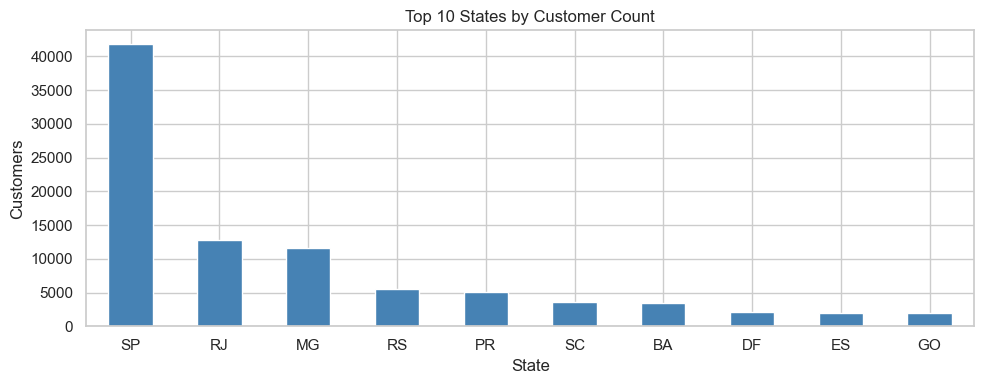


Top state (SP) accounts for 42.0% of customers


In [9]:
# --- 4b. Geographic distribution ---
# Which Brazilian states have the most customers?

top_states = customers['customer_state'].value_counts().head(10)

fig, ax = plt.subplots()
top_states.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 10 States by Customer Count')
ax.set_xlabel('State')
ax.set_ylabel('Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"\nTop state ({top_states.index[0]}) accounts for {top_states.iloc[0]/len(customers)*100:.1f}% of customers")

## 5. Products <a id='products'></a>

Products have an important data quality issue: category names are in Portuguese. There's a separate translation table we'll need to join.

**Questions:**
- What are the most common categories?
- How much missing data is there in the product fields?

In [10]:
# --- 5a. Missing data in products ---
# isnull().sum() on the whole DataFrame gives null counts per column

print("Null counts in products table:")
nulls = products.isnull().sum()
print(nulls[nulls > 0])

Null counts in products table:
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


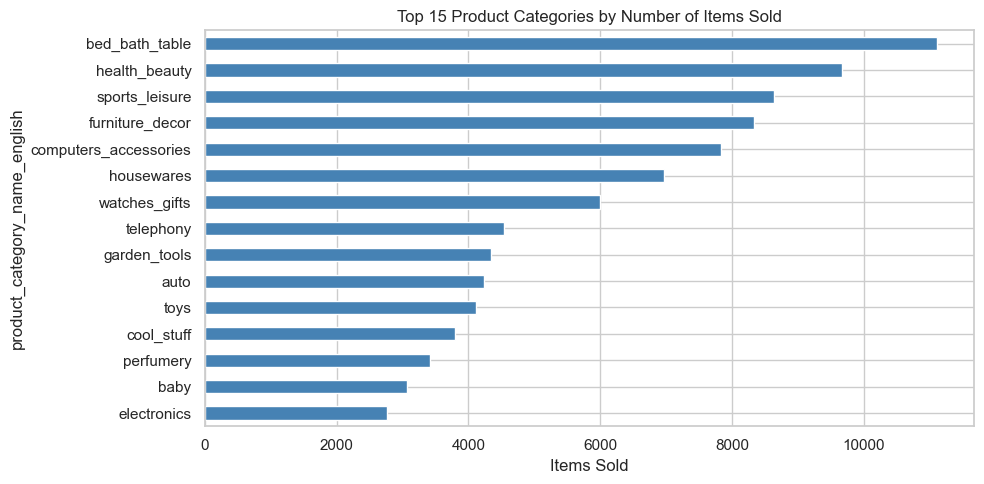

In [11]:
# --- 5b. Top product categories (translated) ---
# We join the translation table to get English category names.
# This is the same as a LEFT JOIN in SQL.

products_translated = products.merge(
    category_translation,
    on='product_category_name',
    how='left'
)

# Count sales per category by joining with order_items
items_with_category = order_items.merge(
    products_translated[['product_id', 'product_category_name_english']],
    on='product_id',
    how='left'
)

top_categories = items_with_category['product_category_name_english'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
top_categories.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 15 Product Categories by Number of Items Sold')
ax.set_xlabel('Items Sold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Reviews <a id='reviews'></a>

Reviews give us customer satisfaction signal. They link to orders via `order_id`.

**Questions:**
- What's the score distribution? (is it skewed?)
- How many orders have no review? (important for left join logic in the mart)

Review Score Distribution:
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

Average score: 4.09


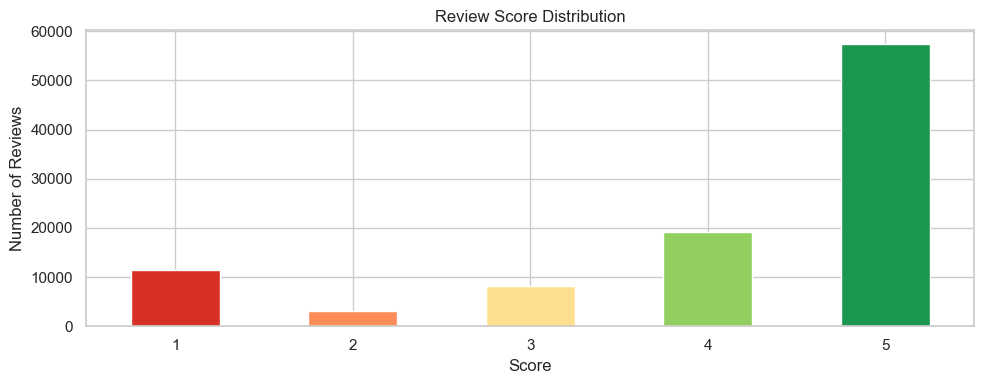

In [12]:
# --- 6a. Review score distribution ---

score_counts = reviews['review_score'].value_counts().sort_index()

print("Review Score Distribution:")
print(score_counts)
print(f"\nAverage score: {reviews['review_score'].mean():.2f}")

fig, ax = plt.subplots()
score_counts.plot(kind='bar', ax=ax,
                  color=['#d73027','#fc8d59','#fee090','#91cf60','#1a9850'],
                  edgecolor='white')
ax.set_title('Review Score Distribution')
ax.set_xlabel('Score')
ax.set_ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [13]:
# --- 6b. Review coverage — how many orders have a review? ---
# We do a left join from orders onto reviews.
# Orders with no matching review will have NaN in review_score after the merge.

orders_with_reviews = orders.merge(
    reviews[['order_id', 'review_score']],
    on='order_id',
    how='left'
)

has_review = orders_with_reviews['review_score'].notna().sum()
no_review  = orders_with_reviews['review_score'].isna().sum()

print(f"Orders with a review:    {has_review:,} ({has_review/len(orders)*100:.1f}%)")
print(f"Orders without a review: {no_review:,} ({no_review/len(orders)*100:.1f}%)")

Orders with a review:    99,224 (99.8%)
Orders without a review: 768 (0.8%)


## 7. Key Findings & Design Decisions <a id='findings'></a>

Fill this in after running the cells above. Template:

### Orders
- X% of orders are `delivered` — the rest (cancelled, unavailable, etc.) we should **exclude from revenue metrics** but **keep in the fact table** with a status flag
- `order_delivered_customer_date` has X% nulls — delivery time calculations must filter to delivered orders only

### Payments
- X% of orders have a single payment row → safe to SUM payments per order
- Credit card dominates at X% → consider a `primary_payment_type` column

### Customers
- X% are one-time buyers → low repeat purchase rate, typical for Brazilian marketplace
- SP (São Paulo) dominates → may want state as a dimension

### Products
- Category name needs translation join → handle this in `dim_products`
- Some products have null categories → need a NULL handling strategy

### Reviews
- X% of orders have a review → use LEFT JOIN in `fct_orders`, not INNER
- Scores are heavily skewed toward 5 — bimodal distribution (1s and 5s)